# Integrantes

* Arthur Maziviero Faria  RM: 573928
* Felipe de Souza Gallo   RM: 569680
* Jun Uehara              RM: 570537
* Matheus Martins Lacerda RM:570843
* Roberson Reguero Luiz Junior RM: 573031
* Tommaso C. Nagliatti RM: 572147

## Importação das bibliotecas

In [1]:
# Importe aqui as bibliotecas necessárias
# Preparação do ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Algoritmo de regressão -----> Regressão Linear
from sklearn.linear_model import LinearRegression
# Separação dos dados para treinamento e para teste (train-test-split)
from sklearn.model_selection import train_test_split
# Métricas de avaliação
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Carregamento do dataset

In [2]:
dados = pd.read_csv('https://raw.githubusercontent.com/JunUehara56/CP4_SERS/refs/heads/main/dados/Data_for_UCI_named.csv')

## Análise do dataset

In [3]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [5]:
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [6]:
dados.shape

(10000, 14)

In [7]:
dados.isnull().sum()

,0
tau1,0
tau2,0
tau3,0
tau4,0
p1,0
p2,0
p3,0
p4,0
g1,0
g2,0


### Registro da análise inicial

**Quantidade de linhas:** 10.000

**Quantidade de colunas:** 14

**Existem valores ausentes?** Não. Todas as 14 colunas possuem 10.000 valores não nulos.

**Observações importantes sobre o dataset:** O dataset possui 10.000 registros e 14 colunas, sendo 13 variáveis numéricas e 1 variável categórica. Não existem valores ausentes. Para a regressão, a variável alvo será `stab`.

## Definição da variável target

In [40]:
# Criar a variável y usando a coluna stab
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## Matriz de correlação

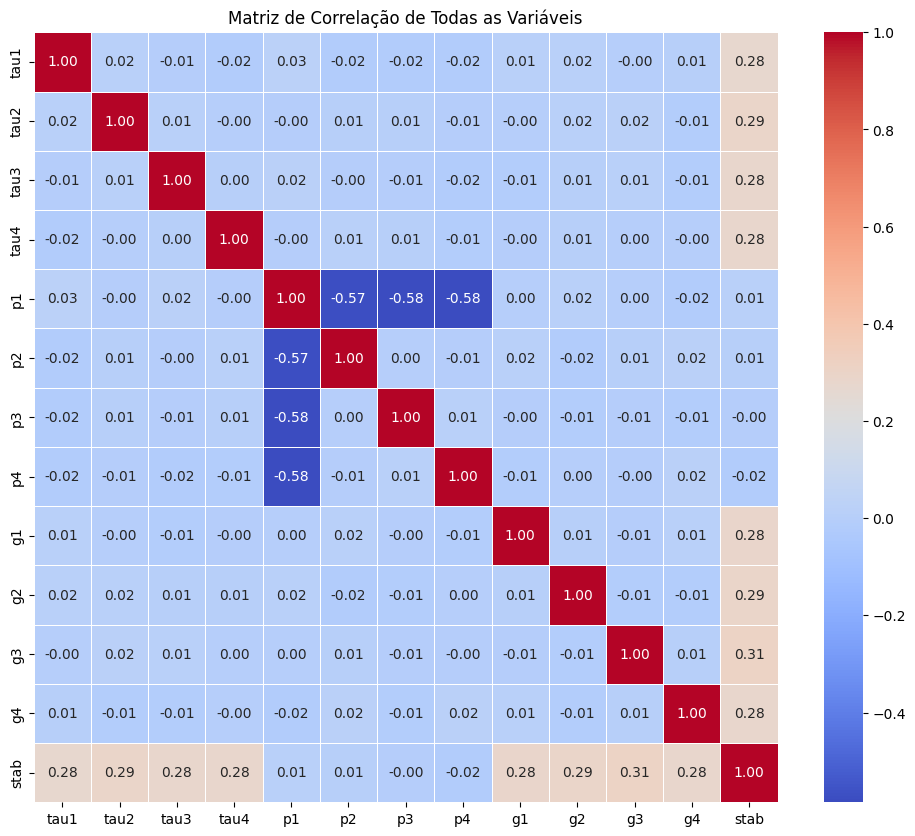

In [48]:
# Calcular e visualizar a matriz de correlação
correlation_matrix = dados.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação de Todas as Variáveis')
plt.show()

# Correlações com stab, desconsiderando a própria coluna
correlacoes_stab = correlation_matrix['stab'].drop('stab')

In [49]:
cinco_variaveis = correlacoes_stab.abs().sort_values(ascending=False).head(5).index.tolist()

print("As 5 variáveis com maior correlação absoluta com stab:")

for variavel in cinco_variaveis:
    print(f"{variavel}: {correlacoes_stab[variavel]:.6f}")

As 5 variáveis com maior correlação absoluta com stab:
g3: 0.308235
g2: 0.293601
tau2: 0.290975
g1: 0.282774
tau3: 0.280700


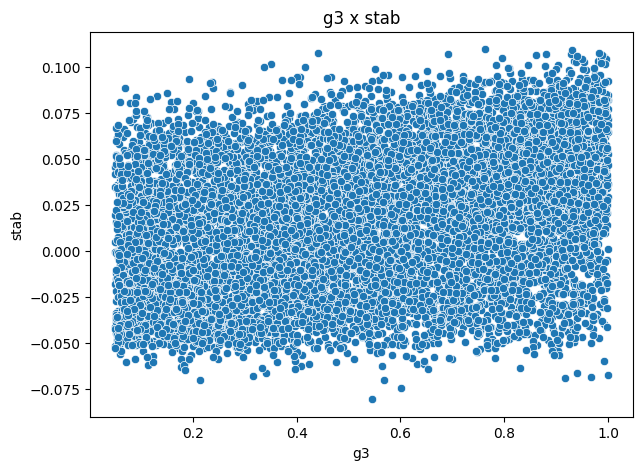

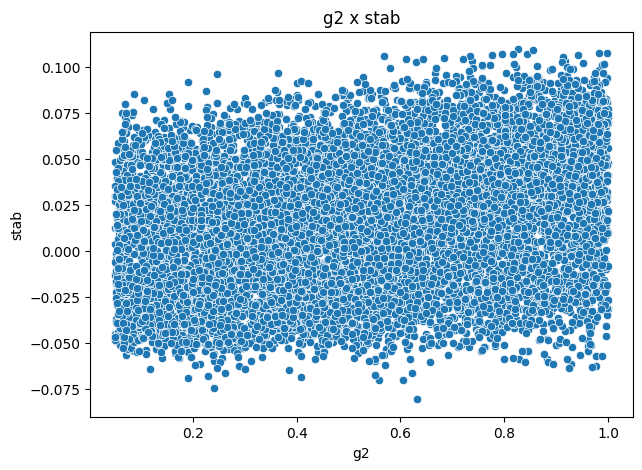

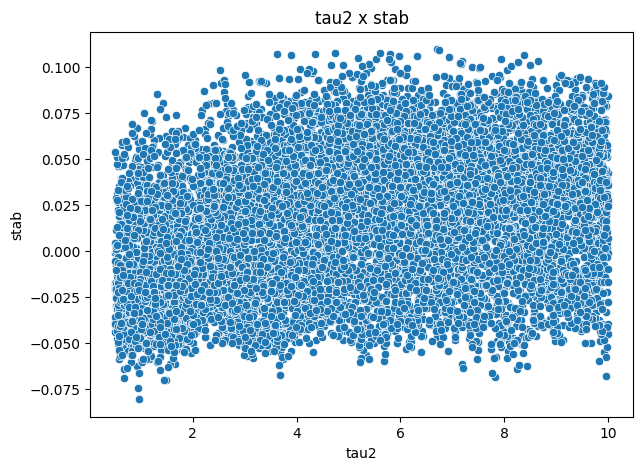

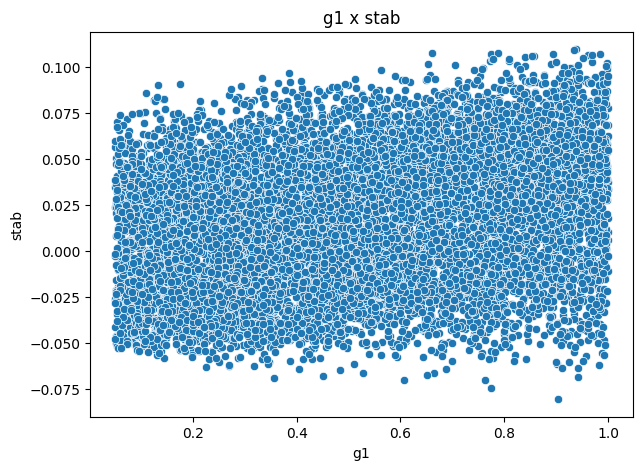

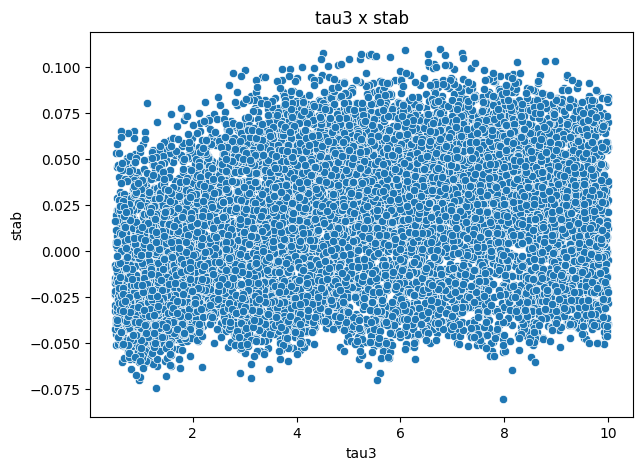

In [50]:
for variavel in cinco_variaveis:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=dados, x=variavel, y='stab')
    plt.title(f'{variavel} x stab')
    plt.xlabel(variavel)
    plt.ylabel('stab')
    plt.show()

## Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

As 5 variáveis com maior correlação absoluta com stab:
g3: 0.308235
g2: 0.293601
tau2: 0.290975
g1: 0.282774
tau3: 0.280700


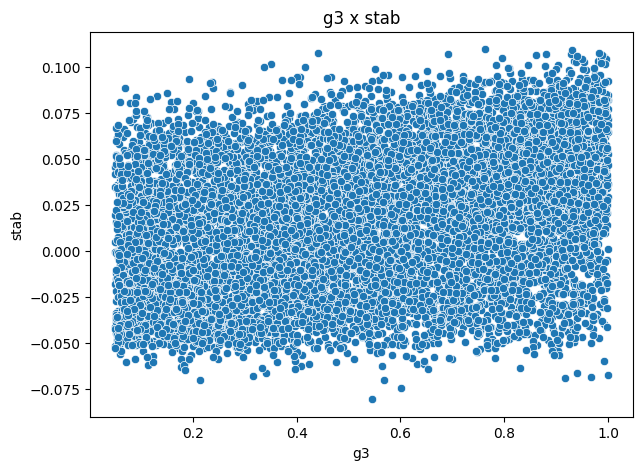

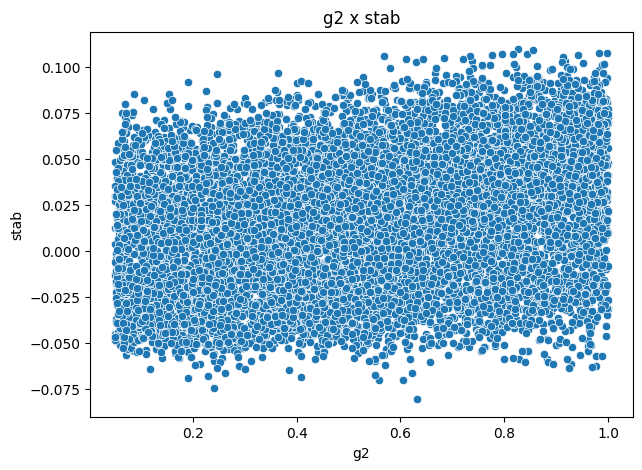

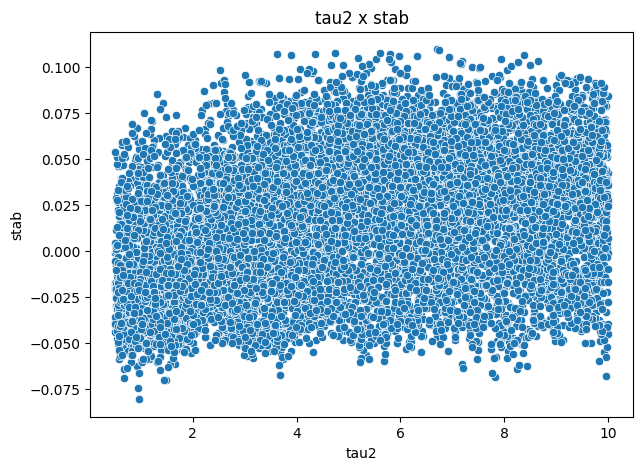

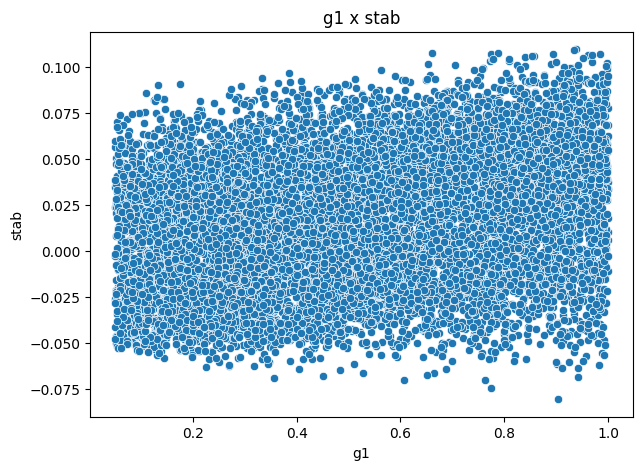

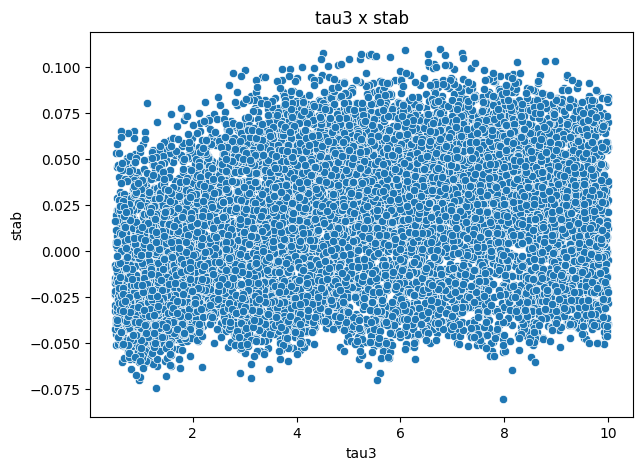

In [51]:
# Colar, revisar e executar o código gerado com o apoio do Gemini
correlation_matrix = dados.corr(numeric_only=True)
correlacoes_stab = correlation_matrix['stab'].drop('stab')

top_5_abs_correlations = correlacoes_stab.abs().sort_values(ascending=False).head(5)
cinco_variaveis = top_5_abs_correlations.index.tolist()

print("As 5 variáveis com maior correlação absoluta com stab:")

for variavel in cinco_variaveis:
    print(f"{variavel}: {correlacoes_stab[variavel]:.6f}")

for variavel in cinco_variaveis:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=dados, x=variavel, y='stab')
    plt.title(f'{variavel} x stab')
    plt.xlabel(variavel)
    plt.ylabel('stab')
    plt.show()

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | g3 | 0,308235 |
| 2 | g2 | 0,293601 |
| 3 | tau2 | 0,290975 |
| 4 | g1 | 0,282774 |
| 5 | tau3 | 0,280700 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta: A variável `g3` apresentou a maior correlação absoluta com `stab`, com coeficiente de 0,308235.

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Os gráficos indicam uma relação linear positiva, porém relativamente fraca, entre as cinco variáveis selecionadas e `stab`. Os pontos apresentam bastante dispersão, mas é possível observar uma tendência geral de aumento de stab à medida que os valores das variáveis aumentam. Entre elas, `g3` apresenta a maior correlação com `stab`, enquanto `tau3` apresenta a menor.

# Modelo 1 – Cinco maiores correlações

In [16]:
# Crie X com as cinco variáveis selecionadas
X = dados[['g3', 'g2', 'tau2', 'g1', 'tau3']]

# Mostre as primeiras linhas
X.head()

,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


## Separação entre treino e teste

In [19]:
# Separação dos dados de treino e teste do Modelo 1
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
print("Quantidade de registros em X_treino:", len(X_treino))
print("Quantidade de registros em X_teste:", len(X_teste))
print("Quantidade de registros em y_treino:", len(y_treino))
print("Quantidade de registros em y_teste:", len(y_teste))

Quantidade de registros em X_treino: 8000
Quantidade de registros em X_teste: 2000
Quantidade de registros em y_treino: 8000
Quantidade de registros em y_teste: 2000


## Treinamento e previsões do Modelo 1

In [20]:
# Treinar o modelo
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

# Gerar y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)

print(y_previsao_1[:10])

[ 0.0478946   0.03781055 -0.00143381 -0.03422274  0.01228364  0.02246186
  0.03723228  0.06337778  0.03332667 -0.00695869]


## Métricas do Modelo 1

In [23]:
# Calcular as três métricas do Modelo 1
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f"R²: {r2_modelo_1:.4f}")
print(f"MAE: {mae_modelo_1:.4f}")
print(f"MSE: {mse_modelo_1:.4f}")

R²: 0.4018
MAE: 0.0233
MSE: 0.0008


# Modelo 2 – Variáveis `tau` e `g`

In [30]:
# Selecionar todas as colunas que começam com tau ou g
colunas_tau_g = [coluna for coluna in dados.columns if coluna.startswith('tau') or coluna.startswith('g')]

X_tau_g = dados[colunas_tau_g]

# Listar as colunas selecionadas
print("Colunas selecionadas:")
print(colunas_tau_g)

# Mostrar as primeiras linhas
X_tau_g.head()

Colunas selecionadas:
['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']


,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## Separação entre treino e teste do Modelo 2

In [35]:
# Separação dos dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)
print("Quantidade de registros em X2_treino:", len(X2_treino))
print("Quantidade de registros em X2_teste:", len(X2_teste))
print("Quantidade de registros em y2_treino:", len(y2_treino))
print("Quantidade de registros em y2_teste:", len(y2_teste))

# Confirmar se y_teste e y2_teste possuem os mesmos índices
print("\nOs índices de teste são iguais?")
print(y_teste.index.equals(y2_teste.index))

Quantidade de registros em X2_treino: 8000
Quantidade de registros em X2_teste: 2000
Quantidade de registros em y2_treino: 8000
Quantidade de registros em y2_teste: 2000

Os índices de teste são iguais?
True


## Treinamento, previsões e métricas do Modelo 2

In [36]:
# Criar e treinar o Modelo 2
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)

# Gerar y_previsao_2
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

# Calcular as três métricas do Modelo 2
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f"R²: {r2_modelo_2:.4f}")
print(f"MAE: {mae_modelo_2:.4f}")
print(f"MSE: {mse_modelo_2:.4f}")

R²: 0.6452
MAE: 0.0176
MSE: 0.0005


# Comparação das métricas dos dois modelos

In [38]:
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': ['g3, g2, tau2, g1, tau3', 'tau1, tau2, tau3, tau4, g1, g2, g3, g4'],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]})

comparacao_modelos

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,"g3, g2, tau2, g1, tau3",0.401770,0.023310,0.000811
1,Modelo 2,"tau1, tau2, tau3, tau4, g1, g2, g3, g4",0.645229,0.017553,0.000481


## Visualização comparativa

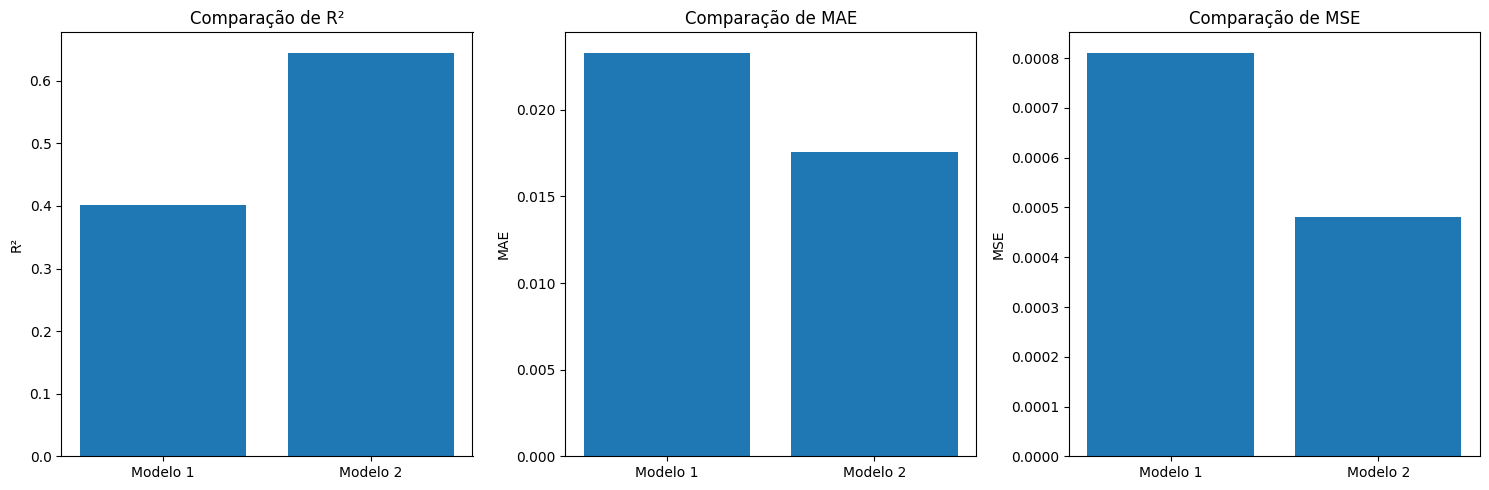

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R²
axes[0].bar(['Modelo 1', 'Modelo 2'], [r2_modelo_1, r2_modelo_2])
axes[0].set_title('Comparação de R²')
axes[0].set_ylabel('R²')

# MAE
axes[1].bar(['Modelo 1', 'Modelo 2'],[mae_modelo_1, mae_modelo_2])
axes[1].set_title('Comparação de MAE')
axes[1].set_ylabel('MAE')

# MSE
axes[2].bar(['Modelo 1', 'Modelo 2'],[mse_modelo_1, mse_modelo_2])
axes[2].set_title('Comparação de MSE')
axes[2].set_ylabel('MSE')

plt.tight_layout()
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o maior R², com 0,645229, enquanto o Modelo 1 apresentou R² de 0,401770.

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o menor MAE, com 0,017553, enquanto o Modelo 1 apresentou MAE de 0,023310.

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o menor MSE, com 0,000481, enquanto o Modelo 1 apresentou MSE de 0,000811.

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim. As três métricas indicaram o Modelo 2. Ele apresentou maior R² (0,645229 contra 0,401770) e menores valores de MAE (0,017553 contra 0,023310) e MSE (0,000481 contra 0,000811).

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: O desempenho melhorou. O R² aumentou de 0,401770 para 0,645229, enquanto o MAE diminuiu de 0,023310 para 0,017553 e o MSE diminuiu de 0,000811 para 0,000481. Isso indica que o conjunto completo de variáveis tau e g permitiu ao modelo explicar melhor a variação de stab e reduzir os erros das previsões.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Eu escolheria o Modelo 2 para prever stab, pois apresentou o maior R² (0,645229), indicando maior capacidade de explicar a variação de stab, além dos menores valores de MAE (0,017553) e MSE (0,000481), indicando menores erros nas previsões.